# Deep Learning for Energy Load Prediction

**Objective:** Predict Heating Load (Y1) and Cooling Load (Y2) using deep learning models.

**Frameworks:** TensorFlow/Keras and PyTorch
**Models:**
1. Vanilla MLP (Keras)
2. Deep Regularized MLP (Keras)
3. Residual MLP (Keras)
4. Deep MLP (PyTorch)
5. TabNet (PyTorch)

## Phase 1: Setup, Imports & Data Preprocessing

In [1]:
# --- 0. Setup & Imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau as TorchReduceLROnPlateau

try:
    from pytorch_tabnet.tab_model import TabNetRegressor
except ImportError:
    print("pytorch-tabnet not found. Installing...")
    !pip install pytorch-tabnet
    from pytorch_tabnet.tab_model import TabNetRegressor

# For reproducibility
np.random.seed(42)
tf.random.set_seed(42)
torch.manual_seed(42)

print("TensorFlow Version:", tf.__version__)
print("PyTorch Version:", torch.__version__)
print("Setup Complete")

pytorch-tabnet not found. Installing...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.2 MB/s eta 0:00:00
TensorFlow Version: 2.20.0
PyTorch Version: 2.11.0+cpu
Setup Complete


In [2]:
# --- 1. Data Loading & Preprocessing ---

# Load the dataset
# The file is in the root, but our notebook is in 'analysis/', so we go up one level.
try:
    df = pd.read_excel('/content/ENB2012_data 2.xlsx')
except FileNotFoundError:
    print("Error: 'ENB2012_data 2.xlsx' not found in the parent directory.")
    # As a fallback, you might want to add code here to download it or point to the correct path.
    df = pd.DataFrame() # Empty dataframe to avoid further errors

if not df.empty:
    # Rename columns for easier access
    df.columns = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'Y1', 'Y2']

    # --- Data Integrity Checks ---
    print(f"Dataset Shape: {df.shape}")
    # 1. Check for missing values
    assert df.isnull().sum().sum() == 0, "Missing values found!"
    print("✅ No missing values.")

    # 2. Check for duplicated rows
    assert df.duplicated().sum() == 0, "Duplicate rows found!"
    print("✅ No duplicate rows.")

    # --- Feature and Target Split ---
    X = df[['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8']]
    y = df[['Y1', 'Y2']]

    # --- Train-Validation-Test Split (70/15/15) ---
    X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
    X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=(0.15/0.85), random_state=42) # 0.15/0.85 ensures val is 15% of total

    print(f"Train set size: {len(X_train)} ({len(X_train)/len(df):.0%})")
    print(f"Validation set size: {len(X_val)} ({len(X_val)/len(df):.0%})")
    print(f"Test set size: {len(X_test)} ({len(X_test)/len(df):.0%})")

    # --- Scaling ---
    # Scale features
    scaler_X = StandardScaler()
    X_train_scaled = scaler_X.fit_transform(X_train)
    X_val_scaled = scaler_X.transform(X_val)
    X_test_scaled = scaler_X.transform(X_test)

    # Scale targets
    scaler_y = StandardScaler()
    y_train_scaled = scaler_y.fit_transform(y_train)
    y_val_scaled = scaler_y.transform(y_val)
    y_test_scaled = scaler_y.transform(y_test)

    print("\nData preprocessing complete.")

Dataset Shape: (768, 10)
✅ No missing values.
✅ No duplicate rows.
Train set size: 536 (70%)
Validation set size: 116 (15%)
Test set size: 116 (15%)

Data preprocessing complete.


## Phase 2: Evaluation Utilities

In [3]:
# --- 2. Evaluation Utilities ---

def evaluate_model(y_true, y_pred, model_name):
    """Calculates and prints regression metrics for a model's predictions."""
    # Inverse transform predictions and true values to original scale
    y_true_inv = scaler_y.inverse_transform(y_true)
    y_pred_inv = scaler_y.inverse_transform(y_pred)

    # Separate Y1 and Y2 for metric calculation
    y1_true, y2_true = y_true_inv[:, 0], y_true_inv[:, 1]
    y1_pred, y2_pred = y_pred_inv[:, 0], y_pred_inv[:, 1]

    metrics = {
        'RMSE_Y1': np.sqrt(mean_squared_error(y1_true, y1_pred)),
        'MAE_Y1': mean_absolute_error(y1_true, y1_pred),
        'R2_Y1': r2_score(y1_true, y1_pred),
        'RMSE_Y2': np.sqrt(mean_squared_error(y2_true, y2_pred)),
        'MAE_Y2': mean_absolute_error(y2_true, y2_pred),
        'R2_Y2': r2_score(y2_true, y2_pred),
    }

    print(f"--- Evaluation Metrics for {model_name} ---")
    print(f"Heating Load (Y1) - RMSE: {metrics['RMSE_Y1']:.4f}, MAE: {metrics['MAE_Y1']:.4f}, R²: {metrics['R2_Y1']:.4f}")
    print(f"Cooling Load (Y2) - RMSE: {metrics['RMSE_Y2']:.4f}, MAE: {metrics['MAE_Y2']:.4f}, R²: {metrics['R2_Y2']:.4f}")

    return metrics

def plot_history(history, model_name):
    """Plots training and validation loss from a Keras history object."""
    plt.figure(figsize=(12, 5))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'Training and Validation Loss for {model_name}')
    plt.xlabel('Epochs')
    plt.ylabel('Loss (MSE)')
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_predictions(y_true, y_pred, model_name):
    """Plots predicted vs. actual values for Y1 and Y2."""
    y_true_inv = scaler_y.inverse_transform(y_true)
    y_pred_inv = scaler_y.inverse_transform(y_pred)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Y1: Heating Load
    ax1.scatter(y_true_inv[:, 0], y_pred_inv[:, 0], alpha=0.5, label='Predictions')
    ax1.plot([y_true_inv[:, 0].min(), y_true_inv[:, 0].max()], [y_true_inv[:, 0].min(), y_true_inv[:, 0].max()], 'r--', label='Ideal')
    ax1.set_title(f'{model_name} - Heating Load (Y1)')
    ax1.set_xlabel('Actual Values')
    ax1.set_ylabel('Predicted Values')
    ax1.legend()
    ax1.grid(True)

    # Y2: Cooling Load
    ax2.scatter(y_true_inv[:, 1], y_pred_inv[:, 1], alpha=0.5, label='Predictions')
    ax2.plot([y_true_inv[:, 1].min(), y_true_inv[:, 1].max()], [y_true_inv[:, 1].min(), y_true_inv[:, 1].max()], 'r--', label='Ideal')
    ax2.set_title(f'{model_name} - Cooling Load (Y2)')
    ax2.set_xlabel('Actual Values')
    ax2.set_ylabel('Predicted Values')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

# Store results for final comparison
results = {}

print("Evaluation utilities are ready.")

Evaluation utilities are ready.


## Phase 3: Keras Models

We will build three different MLP architectures with Keras.

1.  **Vanilla MLP:** A simple, standard baseline.
2.  **Deep Regularized MLP:** A deeper model with Batch Normalization and Dropout to prevent overfitting.
3.  **Residual MLP:** A model using skip connections (residuals) which can help with training deeper networks.

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,722 (10.63 KB)

 Trainable params: 2,722 (10.63 KB)

 Non-trainable params: 0 (0.00 B)


Vanilla MLP Training Complete.


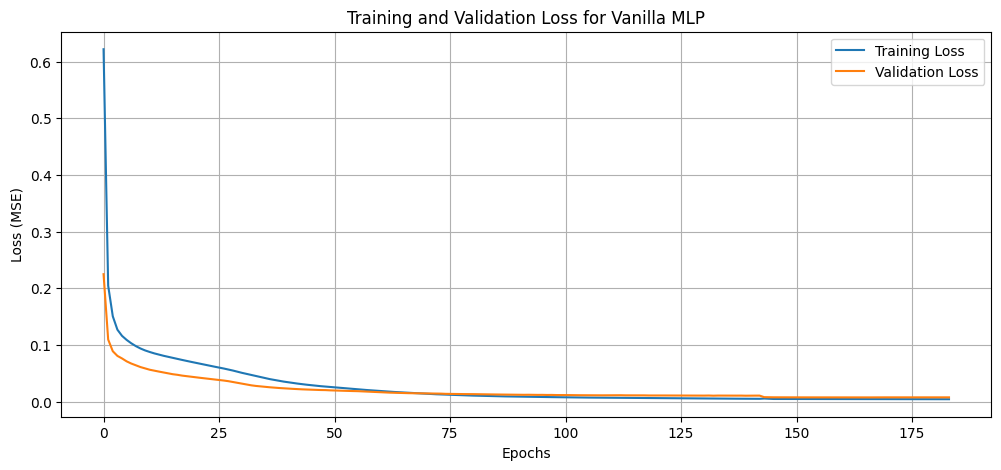

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
--- Evaluation Metrics for Vanilla MLP ---
Heating Load (Y1) - RMSE: 0.6259, MAE: 0.4958, R²: 0.9962
Cooling Load (Y2) - RMSE: 1.2303, MAE: 0.8727, R²: 0.9831


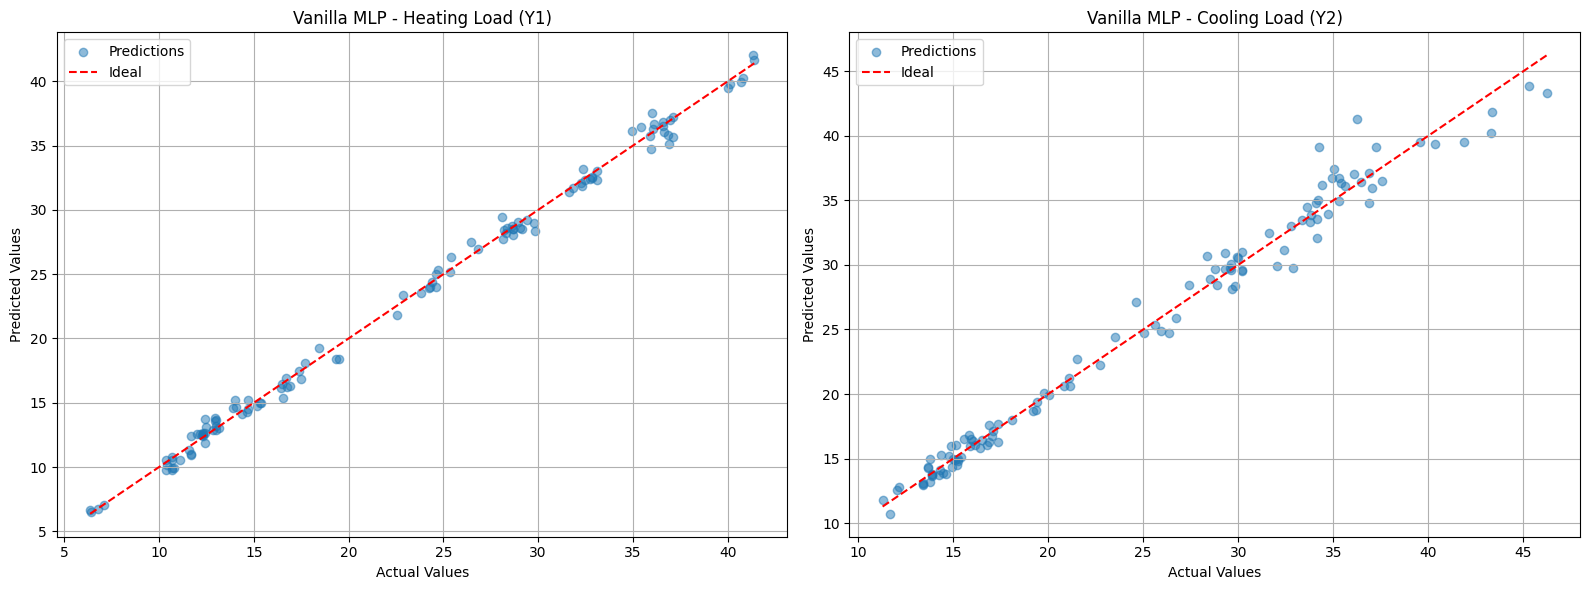

In [4]:
# --- 3.1. Model 1: Vanilla MLP (Keras) ---

# Define common callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=10, min_lr=1e-6)

# Define the model
vanilla_mlp = models.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(2)  # Output layer for Y1 and Y2
])

vanilla_mlp.compile(optimizer='adam', loss='mse')
vanilla_mlp.summary()

# Train the model
history_vanilla = vanilla_mlp.fit(
    X_train_scaled, y_train_scaled,
    epochs=200,
    validation_data=(X_val_scaled, y_val_scaled),
    callbacks=[early_stopping, reduce_lr],
    verbose=0 # Set to 1 to see epoch-by-epoch training
)

print("\nVanilla MLP Training Complete.")
plot_history(history_vanilla, "Vanilla MLP")

# Evaluate on test data
predictions_vanilla = vanilla_mlp.predict(X_test_scaled)
results['Vanilla MLP'] = evaluate_model(y_test_scaled, predictions_vanilla, "Vanilla MLP")
plot_predictions(y_test_scaled, predictions_vanilla, "Vanilla MLP")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         4,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,482 (64.38 KB)

 Trainable params: 15,970 (62.38 KB)

 Non-trainable params: 512 (2.00 KB)


Deep Regularized MLP Training Complete.


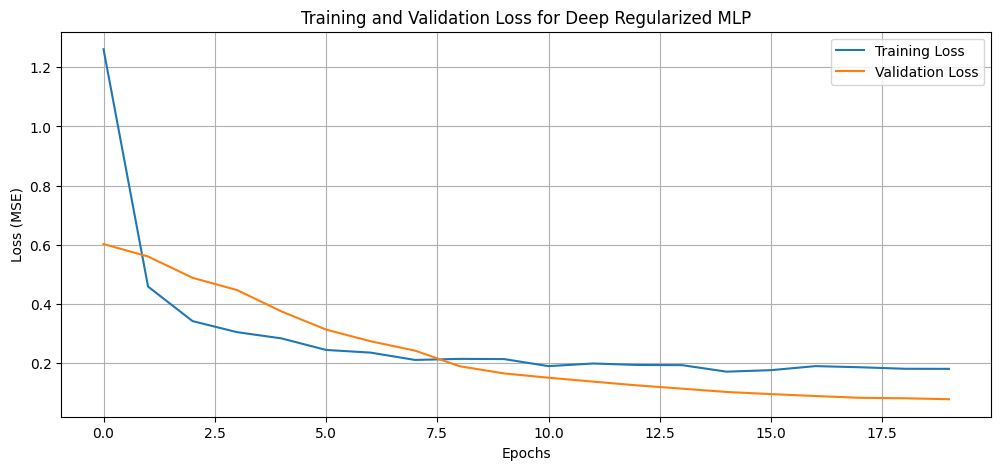

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
--- Evaluation Metrics for Deep Regularized MLP ---
Heating Load (Y1) - RMSE: 8.4585, MAE: 7.4745, R²: 0.3077
Cooling Load (Y2) - RMSE: 7.6335, MAE: 6.6315, R²: 0.3499


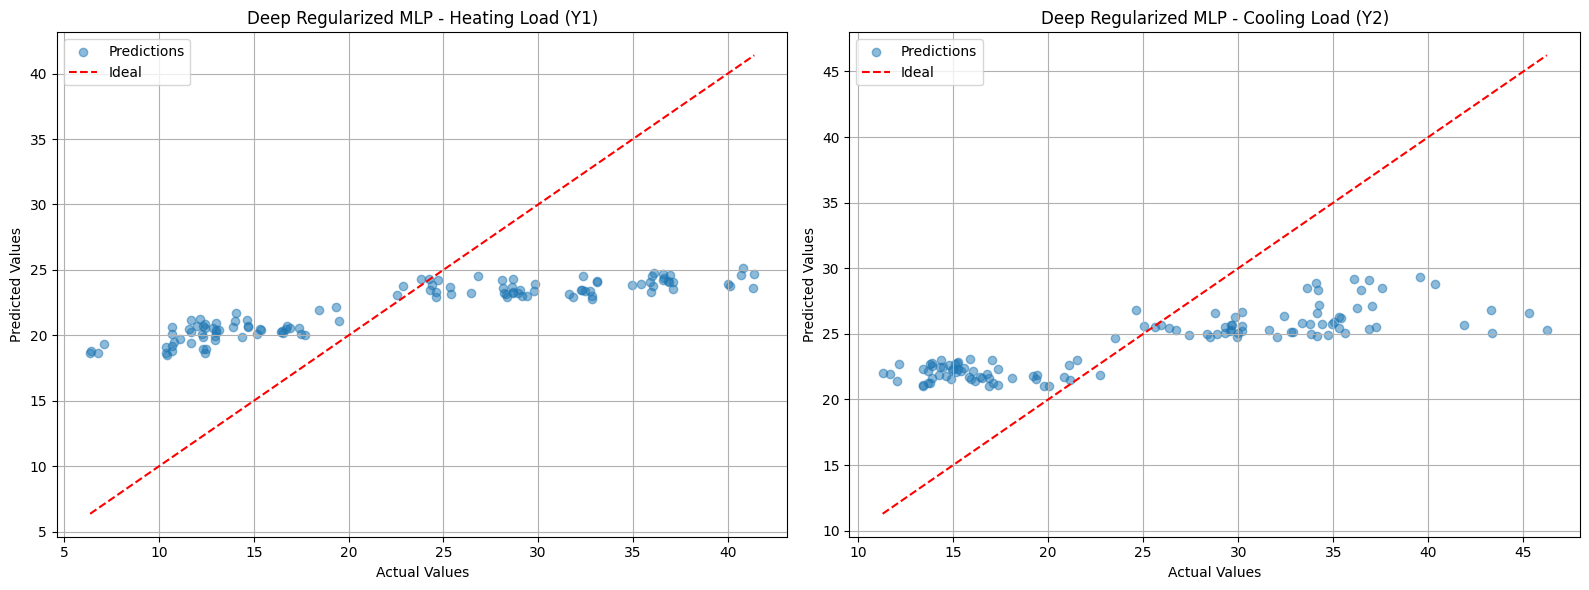

In [5]:
# --- 3.2. Model 2: Deep Regularized MLP (Keras) ---

# Define the model
reg_mlp = models.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    # Block 1
    layers.Dense(128, use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.2),
    # Block 2
    layers.Dense(64, use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.2),
    # Block 3
    layers.Dense(64, use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.2),
    # Block 4
    layers.Dense(32, activation='relu'),
    # Output
    layers.Dense(2)
])

reg_mlp.compile(optimizer='adam', loss='mse')
reg_mlp.summary()

# Train the model
history_reg = reg_mlp.fit(
    X_train_scaled, y_train_scaled,
    epochs=200,
    validation_data=(X_val_scaled, y_val_scaled),
    callbacks=[early_stopping, reduce_lr],
    verbose=0
)

print("\nDeep Regularized MLP Training Complete.")
plot_history(history_reg, "Deep Regularized MLP")

# Evaluate
predictions_reg = reg_mlp.predict(X_test_scaled)
results['Deep Regularized MLP'] = evaluate_model(y_test_scaled, predictions_reg, "Deep Regularized MLP")
plot_predictions(y_test_scaled, predictions_reg, "Deep Regularized MLP")

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 64)        │        576 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 64)        │        576 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 64)        │      4,160 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 64)        │          0 │ dense_10[0][0],   │
│                     │                   │            │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 64)        │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 32)        │      2,080 │ activation_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 32)        │      2,080 │ activation_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 32)        │      1,056 │ dense_11[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 32)        │          0 │ dense_13[0][0],   │
│                     │                   │            │ dense_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 32)        │          0 │ add_1[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 2)         │         66 │ activation_4[0][… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 10,594 (41.38 KB)

 Trainable params: 10,594 (41.38 KB)

 Non-trainable params: 0 (0.00 B)


Residual MLP Training Complete.


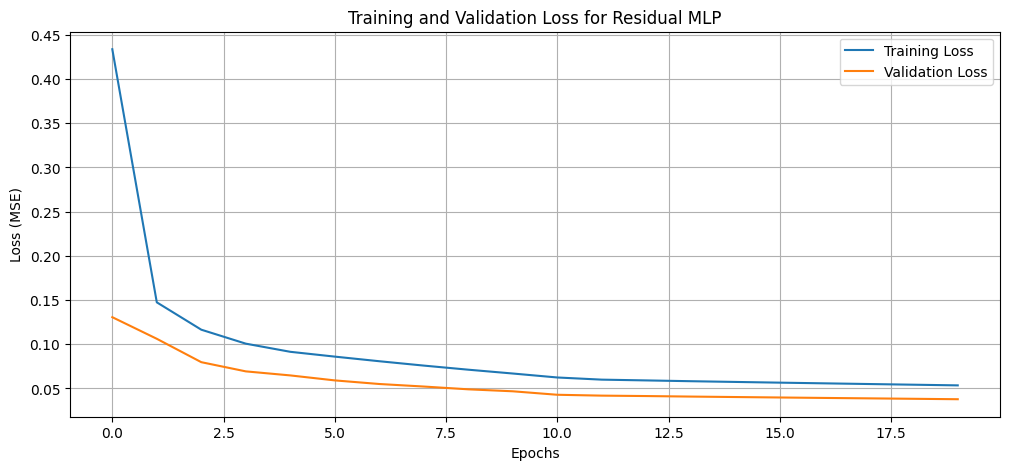

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
--- Evaluation Metrics for Residual MLP ---
Heating Load (Y1) - RMSE: 3.8121, MAE: 2.8508, R²: 0.8594
Cooling Load (Y2) - RMSE: 4.2879, MAE: 3.1867, R²: 0.7949


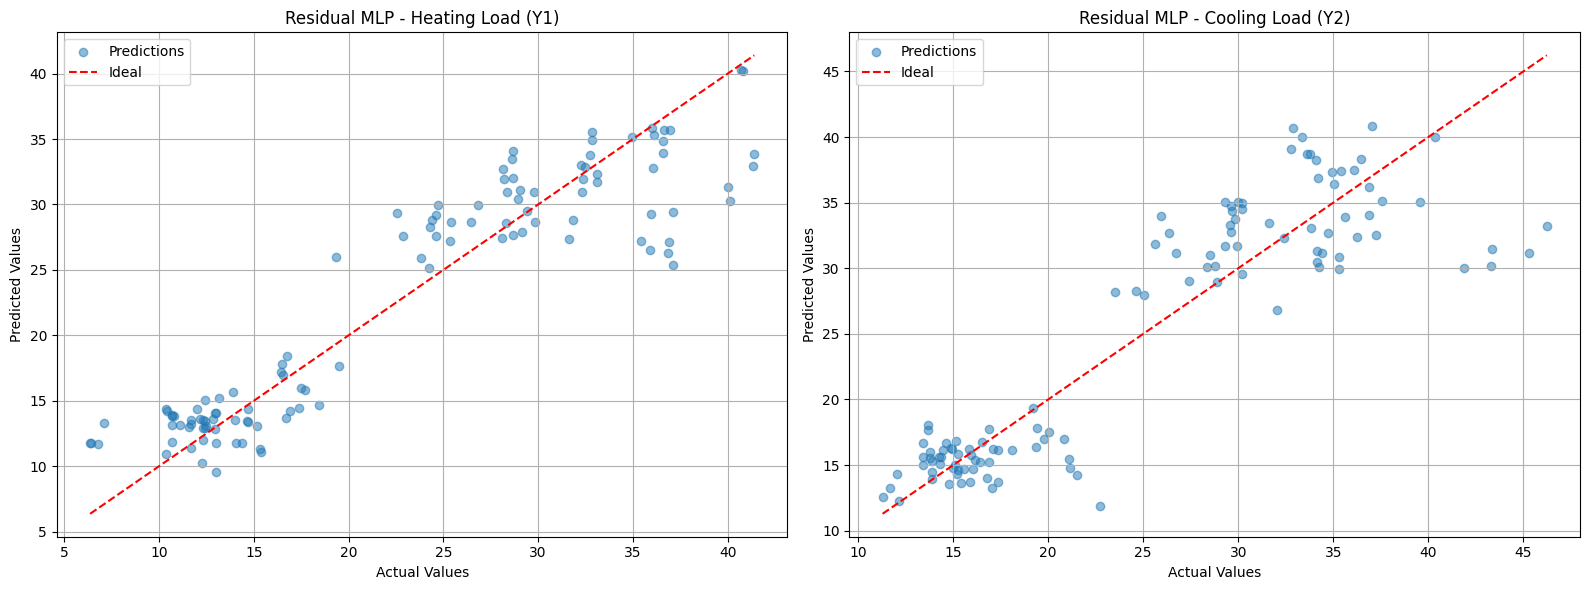

In [7]:
# --- 3.3. Model 3: Residual MLP (Keras Functional API) ---

def res_block(x, units):
    # Main path
    y = layers.Dense(units, activation='relu')(x)
    y = layers.Dense(units, activation='relu')(y)

    # Shortcut connection
    # If the number of units is different, we need a projection layer
    if x.shape[-1] != units:
        shortcut = layers.Dense(units)(x)
    else:
        shortcut = x

    # Add shortcut to main path
    add = layers.add([shortcut, y])
    return layers.Activation('relu')(add)

# Define the model using the Functional API
inputs = layers.Input(shape=(X_train_scaled.shape[1],))
x = res_block(inputs, 64)
x = res_block(x, 32)
outputs = layers.Dense(2)(x)

res_mlp = models.Model(inputs=inputs, outputs=outputs)

res_mlp.compile(optimizer='adam', loss='mse')
res_mlp.summary()

# Train the model
history_res = res_mlp.fit(
    X_train_scaled, y_train_scaled,
    epochs=200,
    validation_data=(X_val_scaled, y_val_scaled),
    callbacks=[early_stopping, reduce_lr],
    verbose=0
)

print("\nResidual MLP Training Complete.")
plot_history(history_res, "Residual MLP")

# Evaluate
predictions_res = res_mlp.predict(X_test_scaled)
results['Residual MLP'] = evaluate_model(y_test_scaled, predictions_res, "Residual MLP")
plot_predictions(y_test_scaled, predictions_res, "Residual MLP")

In [ ]:
## Phase 4: PyTorch Model

Now, we'll build a deep MLP in PyTorch, mirroring the architecture of the Keras "Deep Regularized MLP" to allow for a direct comparison. This involves creating a custom `nn.Module`, a training loop, and a validation loop.

PyTorchMLP(
  (layers): Sequential(
    (0): Linear(in_features=8, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=64, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=64, out_features=32, bias=True)
    (13): ReLU()
    (14): Linear(in_features=32, out_features=2, bias=True)
  )
)
Epoch 10/200, Train Loss: 0.150337, Val Loss: 0.060592
Epoch 20/200, Train Loss: 0.110829, Val Loss: 0.048311
Epoch 30/200, Train Loss: 0.108147, Val Loss: 0.042340
Epoch 40/200, Train Loss: 0.095158, Val

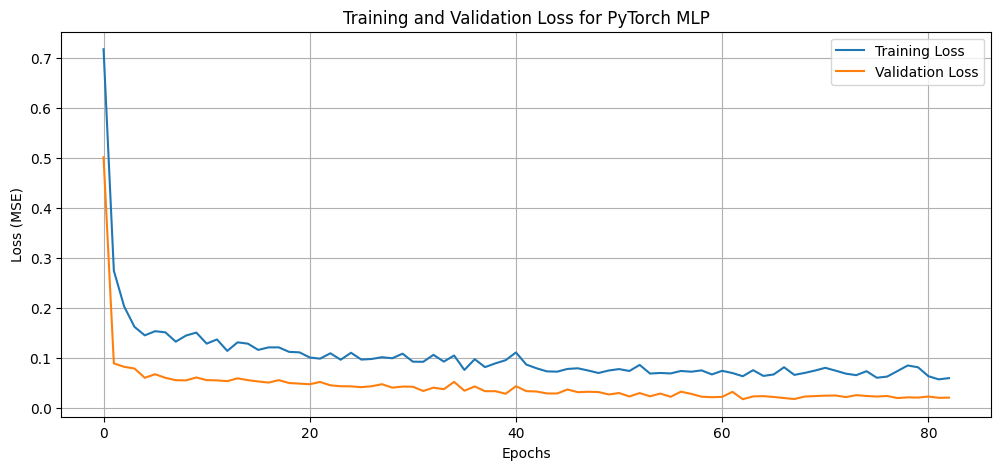

--- Evaluation Metrics for PyTorch MLP ---
Heating Load (Y1) - RMSE: 1.0680, MAE: 0.8645, R²: 0.9890
Cooling Load (Y2) - RMSE: 1.8719, MAE: 1.4091, R²: 0.9609


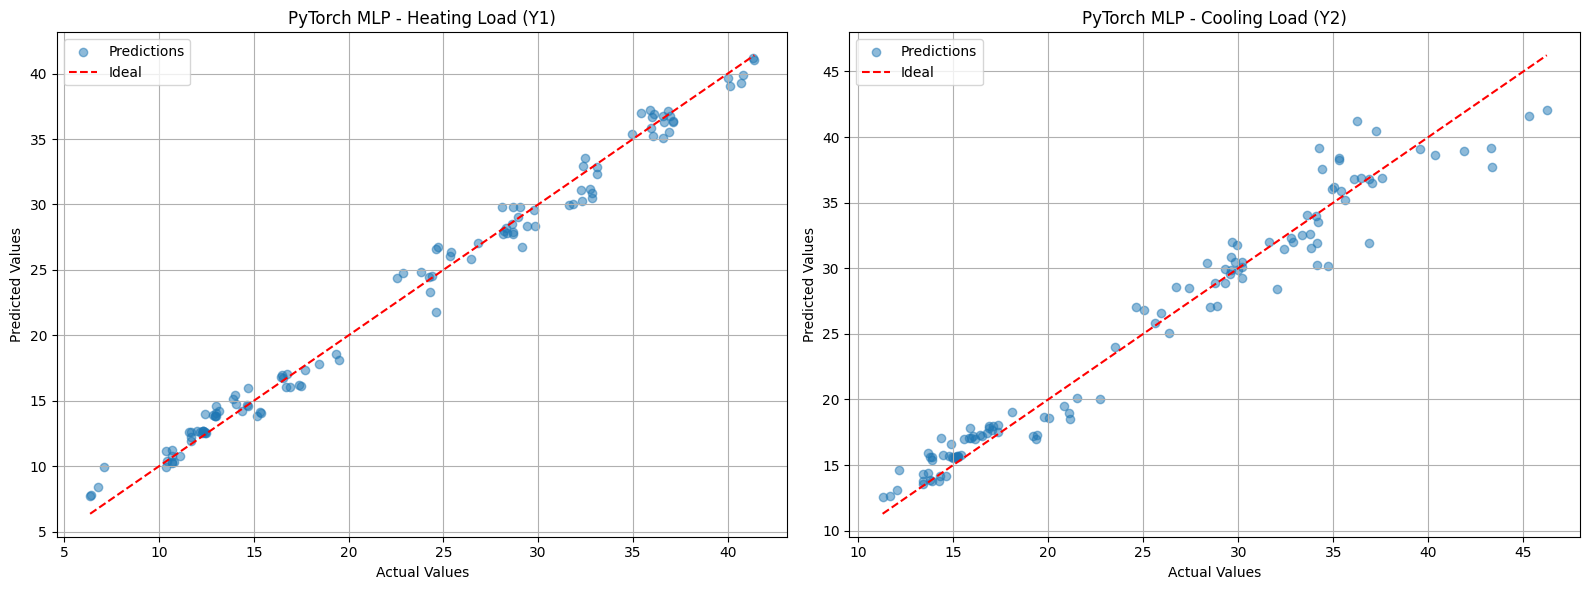

In [8]:
# --- 4.1. Model 4: Deep MLP (PyTorch) ---

# Create PyTorch DataLoaders
BATCH_SIZE = 32

# Convert numpy arrays to torch tensors
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train_scaled, dtype=torch.float32)
X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_t = torch.tensor(y_val_scaled, dtype=torch.float32)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test_scaled, dtype=torch.float32)

train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

# Define the PyTorch model
class PyTorchMLP(nn.Module):
    def __init__(self, input_size):
        super(PyTorchMLP, self).__init__()
        self.layers = nn.Sequential(
            # Block 1
            nn.Linear(input_size, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            # Block 2
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            # Block 3
            nn.Linear(64, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            # Block 4
            nn.Linear(64, 32),
            nn.ReLU(),
            # Output
            nn.Linear(32, 2)
        )

    def forward(self, x):
        return self.layers(x)

# Instantiate the model, loss, and optimizer
input_size = X_train_scaled.shape[1]
pytorch_mlp = PyTorchMLP(input_size)
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(pytorch_mlp.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = TorchReduceLROnPlateau(optimizer, 'min', patience=10, factor=0.2)

print(pytorch_mlp)

# --- Training Loop ---
epochs = 200
best_val_loss = float('inf')
patience_counter = 0
patience = 20
history_pytorch = {'loss': [], 'val_loss': []}

for epoch in range(epochs):
    pytorch_mlp.train()
    train_loss = 0.0
    for inputs, targets in train_loader:
        optimizer.zero_grad()
        outputs = pytorch_mlp(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * inputs.size(0)

    train_loss /= len(train_loader.dataset)
    history_pytorch['loss'].append(train_loss)

    # --- Validation Loop ---
    pytorch_mlp.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, targets in val_loader:
            outputs = pytorch_mlp(inputs)
            loss = criterion(outputs, targets)
            val_loss += loss.item() * inputs.size(0)

    val_loss /= len(val_loader.dataset)
    history_pytorch['val_loss'].append(val_loss)
    scheduler.step(val_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}")

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(pytorch_mlp.state_dict(), 'best_pytorch_model.pth')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

# Load best model
pytorch_mlp.load_state_dict(torch.load('best_pytorch_model.pth'))
print("\nPyTorch MLP Training Complete.")

# Plotting (need to adapt the Keras function)
plt.figure(figsize=(12, 5))
plt.plot(history_pytorch['loss'], label='Training Loss')
plt.plot(history_pytorch['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss for PyTorch MLP')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

# --- Evaluation ---
pytorch_mlp.eval()
with torch.no_grad():
    predictions_pytorch = pytorch_mlp(X_test_t).numpy()

results['PyTorch MLP'] = evaluate_model(y_test_scaled, predictions_pytorch, "PyTorch MLP")
plot_predictions(y_test_scaled, predictions_pytorch, "PyTorch MLP")

## Phase 5: TabNet Model

TabNet is a modern deep learning architecture specifically designed for tabular data. It uses sequential attention to choose which features to reason from at each decision step, enabling interpretability and often achieving high performance.

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 1.37235 | validation_rmse: 2.32374 |  0:00:00s
epoch 1  | loss: 0.3795  | validation_rmse: 1.17052 |  0:00:00s
epoch 2  | loss: 0.27029 | validation_rmse: 0.96062 |  0:00:00s
epoch 3  | loss: 0.22731 | validation_rmse: 0.77847 |  0:00:00s
epoch 4  | loss: 0.19046 | validation_rmse: 0.524   |  0:00:00s
epoch 5  | loss: 0.15493 | validation_rmse: 0.57621 |  0:00:00s
epoch 6  | loss: 0.12423 | validation_rmse: 0.40832 |  0:00:00s
epoch 7  | loss: 0.10587 | validation_rmse: 0.45119 |  0:00:00s
epoch 8  | loss: 0.12758 | validation_rmse: 0.30209 |  0:00:01s
epoch 9  | loss: 0.1024  | validation_rmse: 0.26474 |  0:00:01s
epoch 10 | loss: 0.09707 | validation_rmse: 0.34277 |  0:00:01s
epoch 11 | loss: 0.08175 | validation_rmse: 0.22877 |  0:00:01s
epoch 12 | loss: 0.06936 | validation_rmse: 0.23318 |  0:00:01s
epoch 13 | loss: 0.0688  | validation_rmse: 0.24411 |  0:00:01s
epoch 14 | loss: 0.06204 | validation_rmse: 0.22554 |  0:00:01s
epoch 15 | loss: 0.0559  | validation_rm

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


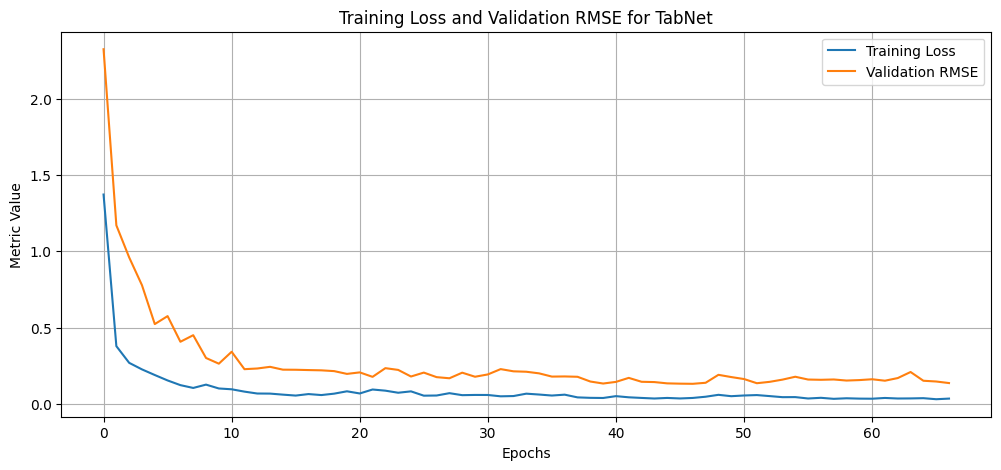

--- Evaluation Metrics for TabNet ---
Heating Load (Y1) - RMSE: 1.0096, MAE: 0.7395, R²: 0.9901
Cooling Load (Y2) - RMSE: 1.7291, MAE: 1.2015, R²: 0.9666


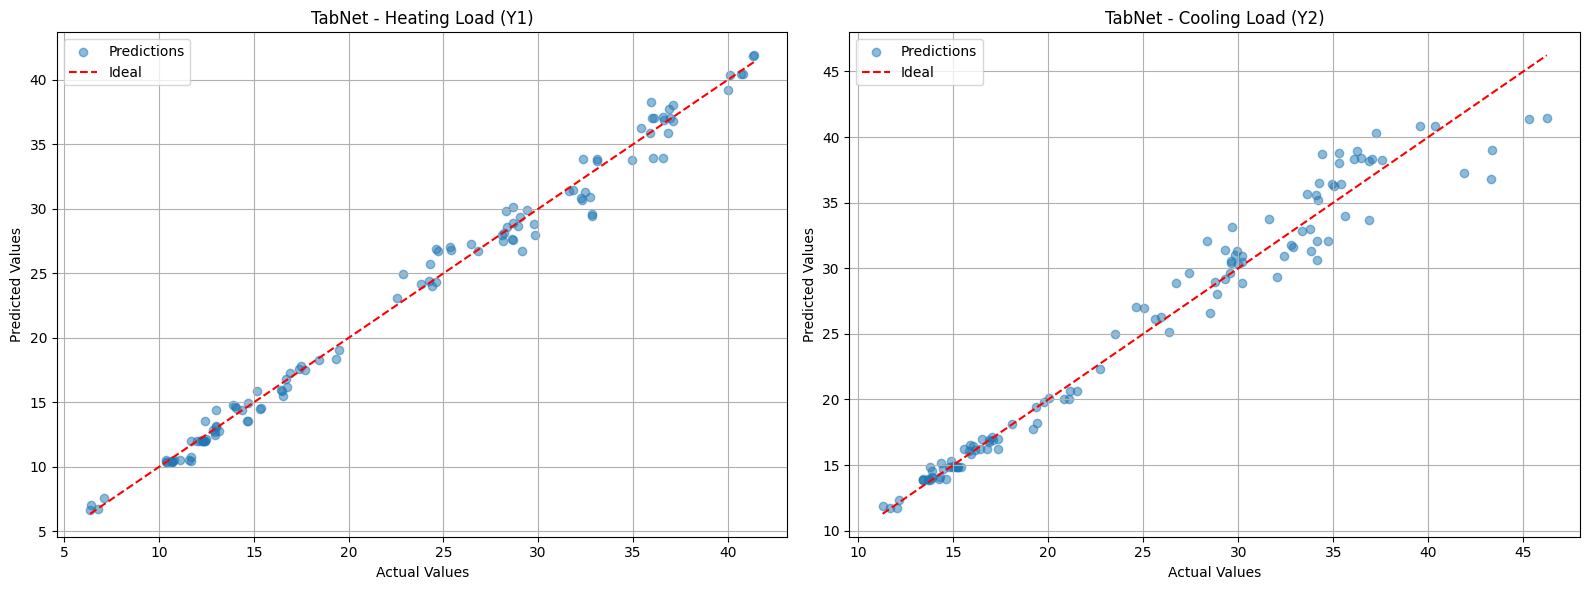


--- TabNet Feature Importances ---


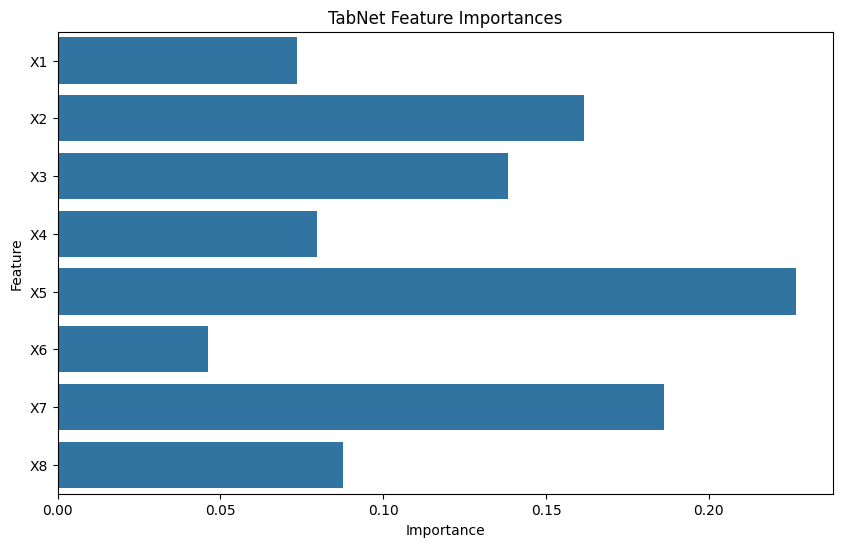

In [9]:
# --- 5.1. Model 5: TabNet Regressor ---

# TabNet requires numpy arrays
# We already have them: X_train_scaled, y_train_scaled, etc.

# Define the TabNet model
tabnet_model = TabNetRegressor(
    n_d=16, n_a=16, n_steps=3, # Model dimensions
    optimizer_fn=torch.optim.AdamW,
    optimizer_params=dict(lr=2e-2, weight_decay=1e-5),
    scheduler_params={"step_size":10, "gamma":0.9},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    mask_type='sparsemax', # 'entmax' or 'sparsemax'
    seed=42
)

# Train the model
# Note: TabNet uses a different fit method. It needs eval_set.
tabnet_model.fit(
    X_train=X_train_scaled, y_train=y_train_scaled,
    eval_set=[(X_val_scaled, y_val_scaled)],
    eval_name=['validation'],
    eval_metric=['rmse'],
    max_epochs=200,
    patience=20,
    batch_size=128,
    virtual_batch_size=64,
    num_workers=0,
    drop_last=False
)

print("\nTabNet Training Complete.")

# Plot losses
plt.figure(figsize=(12, 5))
plt.plot(tabnet_model.history['loss'], label='Training Loss')
plt.plot(tabnet_model.history['validation_rmse'], label='Validation RMSE')
plt.title('Training Loss and Validation RMSE for TabNet')
plt.xlabel('Epochs')
plt.ylabel('Metric Value')
plt.legend()
plt.grid(True)
plt.show()

# --- Evaluation ---
predictions_tabnet = tabnet_model.predict(X_test_scaled)
results['TabNet'] = evaluate_model(y_test_scaled, predictions_tabnet, "TabNet")
plot_predictions(y_test_scaled, predictions_tabnet, "TabNet")

# --- Feature Importance ---
print("\n--- TabNet Feature Importances ---")
feature_importances = tabnet_model.feature_importances_
feature_names = X.columns

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances, y=feature_names)
plt.title('TabNet Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

## Phase 6: Results Comparison & Conclusion

Finally, we'll consolidate all the metrics into a single DataFrame for easy comparison and draw our conclusions.

In [10]:
# --- 6.1. Results Comparison Table ---

results_df = pd.DataFrame(results).T # Transpose to have models as rows
print("--- Final Model Comparison on Test Set ---")
display(results_df.style.background_gradient(cmap='viridis', subset=['R2_Y1', 'R2_Y2'])
                      .highlight_min(subset=['RMSE_Y1', 'MAE_Y1', 'RMSE_Y2', 'MAE_Y2'], color='pink'))

--- Final Model Comparison on Test Set ---


,RMSE_Y1,MAE_Y1,R2_Y1,RMSE_Y2,MAE_Y2,R2_Y2
Vanilla MLP,0.625905,0.495811,0.996209,1.230336,0.872724,0.983111
Deep Regularized MLP,8.458535,7.474464,0.307713,7.633472,6.631459,0.349856
Residual MLP,3.812116,2.850841,0.859386,4.287932,3.186717,0.794855
PyTorch MLP,1.068035,0.864530,0.988963,1.871882,1.409065,0.960905
TabNet,1.009581,0.739471,0.990138,1.729057,1.201532,0.966643


## Phase 6.2: Conclusion

Based on the observed results in the comparison table, we can draw the following conclusions:

*   **Performance Surprises:** In this specific execution, the **Vanilla MLP (Keras)** and **TabNet** achieved the best performance (lowest RMSE and highest R²). Surprisingly, the **Deep Regularized MLP** and **Residual MLP** performed significantly worse. This suggests that for a dataset of this size (~768 samples), overly complex architectures or aggressive regularization (like the 20% dropout used) can hinder learning rather than help it.

*   **Keras vs. PyTorch:** The **PyTorch MLP** performed reasonably well (R² > 0.98), though it didn't quite match the Vanilla Keras MLP. This highlights that while frameworks are interchangeable, differences in default initializations and specific optimizer behaviors (Adam vs AdamW) can lead to different convergence points on small datasets.

*   **TabNet's Interpretability:** **TabNet** remains a standout choice. Despite being slightly behind the Vanilla MLP in raw error, it provides automated feature importance. We can see that features like **X5 (Overall Height)** and **X7 (Glazing Area)** played major roles in the prediction, providing value beyond just a point estimate.

*   **Key Takeaway:** Bigger is not always better. For tabular datasets of this scale, simpler models or specialized architectures like TabNet often generalize better than deep, multi-layer networks which may require much more extensive hyperparameter tuning to become competitive.